# Mining Process – % Silica Concentrate Prediction

This project aims to develop a **machine learning regression model** to predict the **% Silica Concentrate** in a mining flotation process using operational plant data.  
Accurate prediction of silica concentration is essential to improve process efficiency, reduce laboratory dependency, and support real-time decision-making in the field. The code is divided into five main parts, which are:
1. Imports & Configurations;
2. Dataset Treatment;  
3. Applying Ensemble Model; 
4. Result Analysis;
5. Predicting the Future.


**Responsible:** Paulo Casmal

**Email:** <paulo.casmal@gmail.com>

**Start Date:** 01-31-2026 | **Submission Date:** 


---


## 01 - Imports & Configurations

In [ ]:
# import necessary libraries
import locale
import pandas as pd
import numpy as np  
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# import machine learning models to compare performance
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.tsa.arima.model import ARIMA
from sklearn.neural_network import MLPRegressor
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
# Configuration of matplotlib parameters for consistent styling
mpl.rcParams['figure.figsize'] = (10, 5)  # Default figure size
mpl.rc('lines', lw=2)  # Sets the line width
mpl.rcParams['grid.linewidth'] = 0.5  # Grid line width
mpl.rcParams['grid.linestyle'] = 'dashed'  # Grid line style
mpl.rc(('xtick', 'ytick'), labelsize=15)  # Axis tick label size
mpl.rc('font', family='Arial', size=15)  # Font family and font size
mpl.rcParams['axes.linewidth'] = 0.5 # - Largura das bordas dos gráficos

In [3]:
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8') 
except:
    locale.setlocale(locale.LC_ALL, 'portuguese_brazil')

# 2. Informa ao Matplotlib para usar o separador do locale
mpl.rcParams['axes.formatter.use_locale'] = True

In [4]:
# Load the dataset
path = r'C:\Users\paulo\Downloads\archive (2)\MiningProcess_Flotation_Plant_Database.csv'

df = pd.read_csv(path, decimal=',')

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 02 - Dataset treatment

In [5]:
# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [6]:
df.columns

Index(['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

Drop the '% Iron Concentrate' column due to high correlation with target variable. Additionaly, this variable can be measured only at laboratory, which not helps to predict the '% Silica Concentrate' in field.

In [7]:
df = df[['% Iron Concentrate', '% Silica Concentrate']]

In [8]:
df = df.resample("1H").mean()

In [9]:
df = df.drop_duplicates(keep='first')

EDA was performed in a separate script. It does not indicate any major problem with data.

In [10]:
df = df.rename(columns={'% Iron Concentrate': 'Iron_Concentrate', '% Silica Concentrate': 'Silica_Concentrate'})

### 2.3 - Lag Features

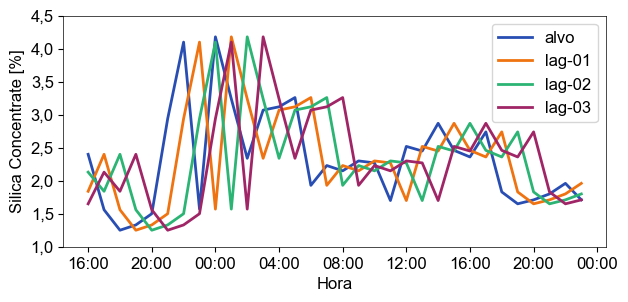

In [27]:
mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size

# Just for visualization purposes
view = df.sort_index().copy()

view = view[view.index > '2017-09-08 00:00:00']

target_col = "Silica_Concentrate"

for lag in range(1, 15):
    view[f"lag-{lag}"] = view[target_col].shift(lag)

view = view.dropna()

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(view.index, view['Silica_Concentrate'], label='alvo', c='#294EB3')
ax.plot(view.index, view['lag-1'], c='#EF7310', label='lag-01')
ax.plot(view.index, view['lag-2'], c='#2BB473', label='lag-02')
ax.plot(view.index, view['lag-3'], c="#A02567", label='lag-03')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.legend()
ax.set_ylabel('Silica Concentrate [%]')
ax.set_xlabel('Hora')

ax.set_yticks(np.arange(1, 5, 0.5))
fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\lag-features.svg', dpi=140, format='svg', transparent=True)

plt.show()


In [15]:
df = df.sort_index()

target_col = "Silica_Concentrate"

for col in df.columns:
    for lag in range(1, 15):
        df[f"{col}-lag-{lag}"] = df[col].shift(lag)

df = df.dropna()

In [16]:
df = df.drop(columns=['Iron_Concentrate'])

### 2.4 - Cross-Validation

In [17]:
# Using specific time series train test split method
tss = TimeSeriesSplit(n_splits=5, test_size=24*14, gap=24) # 14 days data for testing

df = df.sort_index()

df = df.dropna()

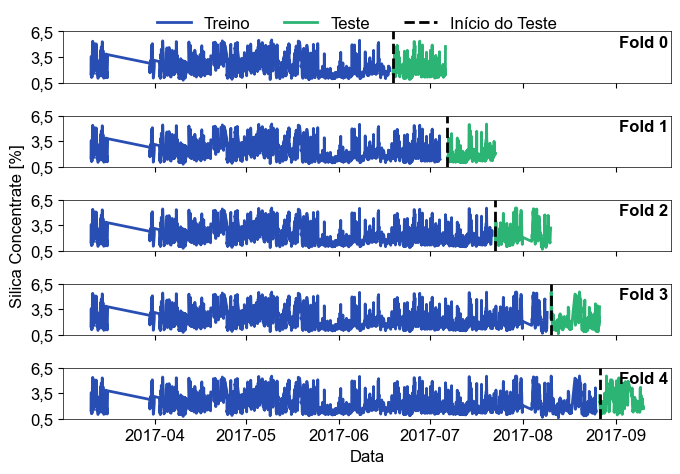

In [48]:
# Just for visualization purposes
fig, axs = plt.subplots(5, 1, figsize=(7, 5), sharex=True)

# Plot each fold
for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    axs[fold].plot(train.index, train['Silica_Concentrate'], label='Treino', c='#294EB3')
    axs[fold].plot(test.index, test['Silica_Concentrate'], label='Teste', c="#2BB473")
    axs[fold].axvline(x=test.index[0], color='k', linestyle='--', label='Início do Teste')

    axs[fold].text(0.915, 0.7, f'Fold {fold}', fontsize=12, transform=axs[fold].transAxes, fontweight='bold')

    axs[fold].set_yticks(np.arange(0.5, 7, 3))
    axs[fold].set_ylim(0.5, 6.5)


axs[2].set_ylabel('Silica Concentrate [%]')

axs[0].legend(ncol=3, loc='upper left', bbox_to_anchor=(0.13, 1.6), frameon=False)

plt.xlabel('Data')
plt.tight_layout()

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\time-series-split.svg', dpi=140, format='svg', transparent=True)

plt.show()

## 03 - Comparing Models

In [ ]:
df.columns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3568 entries, 2017-03-10 16:00:00 to 2017-09-09 23:00:00
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Iron_Concentrate           3568 non-null   float64
 1   Silica_Concentrate         3568 non-null   float64
 2   Iron_Concentrate-lag-1     3568 non-null   float64
 3   Iron_Concentrate-lag-2     3568 non-null   float64
 4   Iron_Concentrate-lag-3     3568 non-null   float64
 5   Iron_Concentrate-lag-4     3568 non-null   float64
 6   Iron_Concentrate-lag-5     3568 non-null   float64
 7   Iron_Concentrate-lag-6     3568 non-null   float64
 8   Iron_Concentrate-lag-7     3568 non-null   float64
 9   Iron_Concentrate-lag-8     3568 non-null   float64
 10  Iron_Concentrate-lag-9     3568 non-null   float64
 11  Iron_Concentrate-lag-10    3568 non-null   float64
 12  Iron_Concentrate-lag-11    3568 non-null   float64
 13  Iron_Concent

In [ ]:
target = 'Silica_Concentrate'
lags_to_test = range(1, 14)

### 3.1 - XGBoost

In [ ]:
# Configurações iniciais
all_results = []

# Loop principal para testar diferentes quantidades de lags
for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO COM {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1. Filtrar colunas dinamicamente
    # Mantemos as originais + lags até o limite n_lags
    cols_to_keep = ['Silica_Concentrate']
    for i in range(1, n_lags + 1):
        cols_to_keep.append(f'Iron_Concentrate-lag-{i}')
        cols_to_keep.append(f'Silica_Concentrate-lag-{i}')
    
    df_filtered = df[cols_to_keep].copy()
    
    # Métricas para este conjunto de lags (média dos folds)
    fold_metrics = []
    temp_best_model = None
    temp_best_rmse = np.inf

    # 2. Cross-Validation (TimeSeriesSplit)
    tss = TimeSeriesSplit(n_splits=5) # Ajuste conforme necessário
    
    for fold, (train_index, test_index) in enumerate(tss.split(df_filtered)):
        train = df_filtered.iloc[train_index]
        test = df_filtered.iloc[test_index]

        X_train_full = train.drop(columns=[target])
        y_train_full = train[target]
        X_test = test.drop(columns=[target])
        y_test = test[target]

        # Split validação para Early Stopping
        split_idx = int(len(X_train_full) * 0.9)
        X_train, X_val = X_train_full.iloc[:split_idx], X_train_full.iloc[split_idx:]
        y_train, y_val = y_train_full.iloc[:split_idx], y_train_full.iloc[split_idx:]

        model = xgb.XGBRegressor(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=3,
            objective='reg:squarederror',
            early_stopping_rounds=50,
            random_state=42
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False # Silenciar para não poluir o terminal
        )

        y_pred = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model

    # 3. Calcular média das métricas deste experimento
    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar dados do experimento
    all_results.append({
        'n_lags': n_lags,
        'rmse_avg': avg_rmse,
        'r2_avg': avg_r2,
        'mae_avg': avg_mae,
        'best_model_obj': temp_best_model,
        'params': model.get_params()
    })

# 4. Rankear e pegar os 3 melhores (pelo RMSE médio)
top_3_results = sorted(all_results, key=lambda x: x['rmse_avg'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES MODELOS")
print("#"*40)

for i, res in enumerate(top_3_results):
    print(f"{i+1}º Lugar: {res['n_lags']} Lags | RMSE Médio: {res['rmse_avg']:.4f}")


 TESTANDO COM 1 LAGS 
Média Final (1 lags) -> RMSE: 0.7617 | R²: 0.4837

 TESTANDO COM 2 LAGS 
Média Final (2 lags) -> RMSE: 0.7395 | R²: 0.5145

 TESTANDO COM 3 LAGS 
Média Final (3 lags) -> RMSE: 0.7434 | R²: 0.5098

 TESTANDO COM 4 LAGS 
Média Final (4 lags) -> RMSE: 0.7633 | R²: 0.4842

 TESTANDO COM 5 LAGS 
Média Final (5 lags) -> RMSE: 0.7651 | R²: 0.4816

 TESTANDO COM 6 LAGS 
Média Final (6 lags) -> RMSE: 0.7759 | R²: 0.4669

 TESTANDO COM 7 LAGS 
Média Final (7 lags) -> RMSE: 0.7771 | R²: 0.4653

 TESTANDO COM 8 LAGS 
Média Final (8 lags) -> RMSE: 0.7748 | R²: 0.4687

 TESTANDO COM 9 LAGS 
Média Final (9 lags) -> RMSE: 0.7730 | R²: 0.4714

 TESTANDO COM 10 LAGS 
Média Final (10 lags) -> RMSE: 0.7725 | R²: 0.4723

 TESTANDO COM 11 LAGS 
Média Final (11 lags) -> RMSE: 0.7740 | R²: 0.4706

 TESTANDO COM 12 LAGS 
Média Final (12 lags) -> RMSE: 0.7723 | R²: 0.4726

 TESTANDO COM 13 LAGS 
Média Final (13 lags) -> RMSE: 0.7743 | R²: 0.4699


########################################


In [ ]:
rmse_list_xgb = []
r2_list_xgb = []
mae_list_xgb = []
lags_xgb = []

for i in range(len(all_results)):
    lags_xgb.append(all_results[i]['n_lags'])
    rmse_list_xgb.append(all_results[i]['rmse_avg'])
    r2_list_xgb.append(all_results[i]['r2_avg'])
    mae_list_xgb.append(all_results[i]['mae_avg'])

### 3.2 - Random Forest

In [ ]:
# Configurações iniciais
all_results_rf = [] # Lista específica para Random Forest

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO RANDOM FOREST: {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1. Filtrar colunas dinamicamente
    cols_to_keep = [target]
    for i in range(1, n_lags + 1):
        cols_to_keep.append(f'Iron_Concentrate-lag-{i}')
        cols_to_keep.append(f'Silica_Concentrate-lag-{i}')
    
    df_filtered = df[cols_to_keep].copy()
    
    fold_metrics = []
    temp_best_model = None
    temp_best_rmse = np.inf

    # 2. Cross-Validation
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df_filtered)):
        train = df_filtered.iloc[train_index]
        test = df_filtered.iloc[test_index]

        X_train = train.drop(columns=[target])
        y_train = train[target]
        X_test = test.drop(columns=[target])
        y_test = test[target]

        # Instanciando Random Forest
        # Usei n_estimators=200 para equilíbrio entre performance e tempo, 
        # mas você pode aumentar para 500 ou 1000 se o PC aguentar.
        model_rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=10, # RF geralmente precisa de mais profundidade que XGBoost
            random_state=42,
            n_jobs=-1 # Usa todos os núcleos do seu processador
        )

        model_rf.fit(X_train, y_train)

        y_pred = model_rf.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model_rf

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final RF ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar com sufixo rfs para futura comparação
    all_results_rf.append({
        'n_lags_rfs': n_lags,
        'rmse_avg_rfs': avg_rmse,
        'r2_avg_rfs': avg_r2,
        'mae_avg_rfs': avg_mae,
        'model_obj_rfs': temp_best_model,
        'params_rfs': model_rf.get_params()
    })

# 4. Rankear Top 3
top_3_rf = sorted(all_results_rf, key=lambda x: x['rmse_avg_rfs'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - RANDOM FOREST")
print("#"*40)
for i, res in enumerate(top_3_rf):
    print(f"{i+1}º Lugar: {res['n_lags_rfs']} Lags | RMSE Médio: {res['rmse_avg_rfs']:.4f}")


 TESTANDO RANDOM FOREST: 1 LAGS 
Média Final RF (1 lags) -> RMSE: 0.7830 | R²: 0.4518

 TESTANDO RANDOM FOREST: 2 LAGS 
Média Final RF (2 lags) -> RMSE: 0.7531 | R²: 0.4944

 TESTANDO RANDOM FOREST: 3 LAGS 
Média Final RF (3 lags) -> RMSE: 0.7533 | R²: 0.4950

 TESTANDO RANDOM FOREST: 4 LAGS 
Média Final RF (4 lags) -> RMSE: 0.7557 | R²: 0.4920

 TESTANDO RANDOM FOREST: 5 LAGS 
Média Final RF (5 lags) -> RMSE: 0.7594 | R²: 0.4863

 TESTANDO RANDOM FOREST: 6 LAGS 
Média Final RF (6 lags) -> RMSE: 0.7632 | R²: 0.4821

 TESTANDO RANDOM FOREST: 7 LAGS 
Média Final RF (7 lags) -> RMSE: 0.7617 | R²: 0.4845

 TESTANDO RANDOM FOREST: 8 LAGS 
Média Final RF (8 lags) -> RMSE: 0.7626 | R²: 0.4836

 TESTANDO RANDOM FOREST: 9 LAGS 
Média Final RF (9 lags) -> RMSE: 0.7609 | R²: 0.4864

 TESTANDO RANDOM FOREST: 10 LAGS 
Média Final RF (10 lags) -> RMSE: 0.7613 | R²: 0.4863

 TESTANDO RANDOM FOREST: 11 LAGS 
Média Final RF (11 lags) -> RMSE: 0.7609 | R²: 0.4867

 TESTANDO RANDOM FOREST: 12 LAGS 
Médi

In [ ]:
rmse_list_rf = []
r2_list_rf = []
mae_list_rf = []
lags_rf = []

for i in range(len(all_results_rf)):
    lags_rf.append(all_results_rf[i]['n_lags_rfs'])
    rmse_list_rf.append(all_results_rf[i]['rmse_avg_rfs'])
    r2_list_rf.append(all_results_rf[i]['r2_avg_rfs'])
    mae_list_rf.append(all_results_rf[i]['mae_avg_rfs'])

### 3.3 - Multi Layer Perceptron

In [ ]:
# Configurações iniciais
all_results_mlp = [] # Lista específica para MLP

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO MLP (REDE NEURAL): {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1. Filtrar colunas dinamicamente
    cols_to_keep = [target]
    for i in range(1, n_lags + 1):
        cols_to_keep.append(f'Iron_Concentrate-lag-{i}')
        cols_to_keep.append(f'Silica_Concentrate-lag-{i}')
    
    df_filtered = df[cols_to_keep].copy()
    
    fold_metrics = []
    temp_best_model = None
    temp_best_rmse = np.inf

    # 2. Cross-Validation
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df_filtered)):
        train = df_filtered.iloc[train_index]
        test = df_filtered.iloc[test_index]

        X_train_raw = train.drop(columns=[target])
        y_train = train[target]
        X_test_raw = test.drop(columns=[target])
        y_test = test[target]

        # --- IMPORTANTE: Escalonamento de Dados para MLP ---
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # Instanciando MLP
        # Arquitetura (64, 32) costuma ser um bom ponto de partida para regressão
        model_mlp = MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        )

        model_mlp.fit(X_train, y_train)

        y_pred = model_mlp.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model_mlp

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final MLP ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar com sufixo mlps
    all_results_mlp.append({
        'n_lags_mlps': n_lags,
        'rmse_avg_mlps': avg_rmse,
        'r2_avg_mlps': avg_r2,
        'mae_avg_mlps': avg_mae,
        'model_obj_mlps': temp_best_model,
        'params_mlps': model_mlp.get_params()
    })

# 4. Rankear Top 3
top_3_mlp = sorted(all_results_mlp, key=lambda x: x['rmse_avg_mlps'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - MLP")
print("#"*40)
for i, res in enumerate(top_3_mlp):
    print(f"{i+1}º Lugar: {res['n_lags_mlps']} Lags | RMSE Médio: {res['rmse_avg_mlps']:.4f}")


 TESTANDO MLP (REDE NEURAL): 1 LAGS 
Média Final MLP (1 lags) -> RMSE: 0.7357 | R²: 0.5174

 TESTANDO MLP (REDE NEURAL): 2 LAGS 
Média Final MLP (2 lags) -> RMSE: 0.7258 | R²: 0.5315

 TESTANDO MLP (REDE NEURAL): 3 LAGS 
Média Final MLP (3 lags) -> RMSE: 0.7293 | R²: 0.5251

 TESTANDO MLP (REDE NEURAL): 4 LAGS 
Média Final MLP (4 lags) -> RMSE: 0.7335 | R²: 0.5197

 TESTANDO MLP (REDE NEURAL): 5 LAGS 
Média Final MLP (5 lags) -> RMSE: 0.7409 | R²: 0.5076

 TESTANDO MLP (REDE NEURAL): 6 LAGS 
Média Final MLP (6 lags) -> RMSE: 0.7429 | R²: 0.5085

 TESTANDO MLP (REDE NEURAL): 7 LAGS 
Média Final MLP (7 lags) -> RMSE: 0.7599 | R²: 0.4897

 TESTANDO MLP (REDE NEURAL): 8 LAGS 
Média Final MLP (8 lags) -> RMSE: 0.7697 | R²: 0.4729

 TESTANDO MLP (REDE NEURAL): 9 LAGS 
Média Final MLP (9 lags) -> RMSE: 0.7832 | R²: 0.4554

 TESTANDO MLP (REDE NEURAL): 10 LAGS 
Média Final MLP (10 lags) -> RMSE: 0.7927 | R²: 0.4423

 TESTANDO MLP (REDE NEURAL): 11 LAGS 
Média Final MLP (11 lags) -> RMSE: 0.78

In [ ]:
rmse_list_mlp = []
r2_list_mlp = []
mae_list_mlp = []
lags_mlp = []

for i in range(len(all_results_mlp)):
    lags_mlp.append(all_results_mlp[i]['n_lags_mlps'])
    rmse_list_mlp.append(all_results_mlp[i]['rmse_avg_mlps'])
    r2_list_mlp.append(all_results_mlp[i]['r2_avg_mlps'])
    mae_list_mlp.append(all_results_mlp[i]['mae_avg_mlps'])

### 3.4 - SARIMA

In [ ]:
all_results_arima = []

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO ARIMA/ARMA: {n_lags} LAGS (p={n_lags}) ")
    print(f"{'='*30}")

    # No ARIMA, os lags da variável alvo são definidos pelo parâmetro 'p'
    # Mas para manter a paridade com os outros modelos, vamos usar as variáveis exógenas lagadas
    cols_exog = []
    for i in range(1, n_lags + 1):
        cols_exog.append(f'Iron_Concentrate-lag-{i}')
        cols_exog.append(f'Silica_Concentrate-lag-{i}')
    
    fold_metrics = []
    temp_best_rmse = np.inf
    temp_best_model = None

    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df)):
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        y_train = train[target]
        X_train_exog = train[cols_exog]
        
        y_test = test[target]
        X_test_exog = test[cols_exog]

        # Configuração do Modelo:
        # order=(p, d, q)
        # ARMA é quando d=0. ARIMA quando d=1 (se a série não for estacionária).
        # Vamos testar como ARMA (d=0) para comparar com os lags puros.
        model_arima = SARIMAX(
            y_train, 
            exog=X_train_exog, 
            order=(n_lags, 0, 0), # n_lags aqui define a parte AutoRegressiva (p)
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model_arima.fit(disp=False)

        # Previsão (passamos as variáveis exógenas do teste)
        y_pred = model_fit.forecast(steps=len(y_test), exog=X_test_exog)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model_fit

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final ARIMA ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    all_results_arima.append({
        'n_lags_arimas': n_lags,
        'rmse_avg_arimas': avg_rmse,
        'r2_avg_arimas': avg_r2,
        'mae_avg_arimas': avg_mae,
        'model_obj_arimas': temp_best_model
    })

top_3_arima = sorted(all_results_arima, key=lambda x: x['rmse_avg_arimas'])[:3]


 TESTANDO ARIMA/ARMA: 1 LAGS (p=1) 
Média Final ARIMA (1 lags) -> RMSE: 0.7335 | R²: 0.5183

 TESTANDO ARIMA/ARMA: 2 LAGS (p=2) 
Média Final ARIMA (2 lags) -> RMSE: 0.7791 | R²: 0.4558

 TESTANDO ARIMA/ARMA: 3 LAGS (p=3) 
Média Final ARIMA (3 lags) -> RMSE: 0.7258 | R²: 0.5311

 TESTANDO ARIMA/ARMA: 4 LAGS (p=4) 
Média Final ARIMA (4 lags) -> RMSE: 0.7280 | R²: 0.5289

 TESTANDO ARIMA/ARMA: 5 LAGS (p=5) 
Média Final ARIMA (5 lags) -> RMSE: 0.7291 | R²: 0.5277

 TESTANDO ARIMA/ARMA: 6 LAGS (p=6) 
Média Final ARIMA (6 lags) -> RMSE: 0.7230 | R²: 0.5349

 TESTANDO ARIMA/ARMA: 7 LAGS (p=7) 
Média Final ARIMA (7 lags) -> RMSE: 0.7230 | R²: 0.5349

 TESTANDO ARIMA/ARMA: 8 LAGS (p=8) 
Média Final ARIMA (8 lags) -> RMSE: 0.7521 | R²: 0.4941

 TESTANDO ARIMA/ARMA: 9 LAGS (p=9) 
Média Final ARIMA (9 lags) -> RMSE: 0.7326 | R²: 0.5242

 TESTANDO ARIMA/ARMA: 10 LAGS (p=10) 
Média Final ARIMA (10 lags) -> RMSE: 0.7294 | R²: 0.5275

 TESTANDO ARIMA/ARMA: 11 LAGS (p=11) 
Média Final ARIMA (11 lags) 

In [ ]:
rmse_list_arima = []
r2_list_arima = []
mae_list_arima = []
lags_arima = []

for i in range(13):
    lags_arima.append(all_results_arima[i]['n_lags_arimas'])
    rmse_list_arima.append(all_results_arima[i]['rmse_avg_arimas'])
    r2_list_arima.append(all_results_arima[i]['r2_avg_arimas'])
    mae_list_arima.append(all_results_arima[i]['mae_avg_arimas'])


### 3.5 - Long-Short Term Memory (LSTM)

In [ ]:
all_results_lstm = []

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO LSTM: {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1. Preparação das colunas
    cols_features = []
    for i in range(1, n_lags + 1):
        cols_features.append(f'Iron_Concentrate-lag-{i}')
        cols_features.append(f'Silica_Concentrate-lag-{i}')
    
    fold_metrics = []
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df)):
        # Split e Escalonamento (Obrigatório para Redes Neurais)
        scaler_X = StandardScaler()
        
        X_train_raw = df.iloc[train_index][cols_features]
        y_train = df.iloc[train_index][target]
        X_test_raw = df.iloc[test_index][cols_features]
        y_test = df.iloc[test_index][target]

        X_train_scaled = scaler_X.fit_transform(X_train_raw)
        X_test_scaled = scaler_X.transform(X_test_raw)

        # --- RESHAPE PARA 3D [samples, time_steps, features] ---
        # Aqui tratamos cada lag como um passo no tempo. 
        # Temos 2 features (Iron e Silica) por passo de tempo.
        X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], n_lags, 2))
        X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], n_lags, 2))

        # 2. Construção da Arquitetura LSTM
        model_lstm = Sequential([
            LSTM(50, activation='relu', input_shape=(n_lags, 2)),
            Dropout(0.2),
            Dense(1)
        ])
        model_lstm.compile(optimizer='adam', loss='mse')

        # 3. Treinamento com Early Stopping para evitar Overfitting
        es = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)
        
        model_lstm.fit(
            X_train_3d, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.1,
            callbacks=[es],
            verbose=0
        )

        # 4. Predição e Métricas
        y_pred = model_lstm.predict(X_test_3d).flatten()
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2})

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])

    print(f"Média Final LSTM ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    all_results_lstm.append({
        'n_lags_lstms': n_lags,
        'rmse_avg_lstms': avg_rmse,
        'r2_avg_lstms': avg_r2
    })


 TESTANDO LSTM: 1 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Média Final LSTM (1 lags) -> RMSE: 0.7430 | R²: 0.5093

 TESTANDO LSTM: 2 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Média Final LSTM (2 lags) -> RMSE: 0.7217 | R²: 0.5368

 TESTANDO LSTM: 3 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Média Final LSTM (3 lags) -> RMSE: 0.7259 | R²: 0.5327

 TESTANDO LSTM: 4 LAGS 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
19/19 ━━━━━━━━━

In [ ]:
rmse_list_lstm = []
r2_list_lstm = []
mae_list_lstm = []
lags_lstm = []

for i in range(len(all_results_lstm)):
    lags_lstm.append(all_results_lstm[i]['n_lags_lstms'])
    rmse_list_lstm.append(all_results_lstm[i]['rmse_avg_lstms'])
    r2_list_lstm.append(all_results_lstm[i]['r2_avg_lstms'])
    # mae_list_lstm.append(all_results_lstm[i]['mae_avg_lstms'])

## 04 - Result Analysis

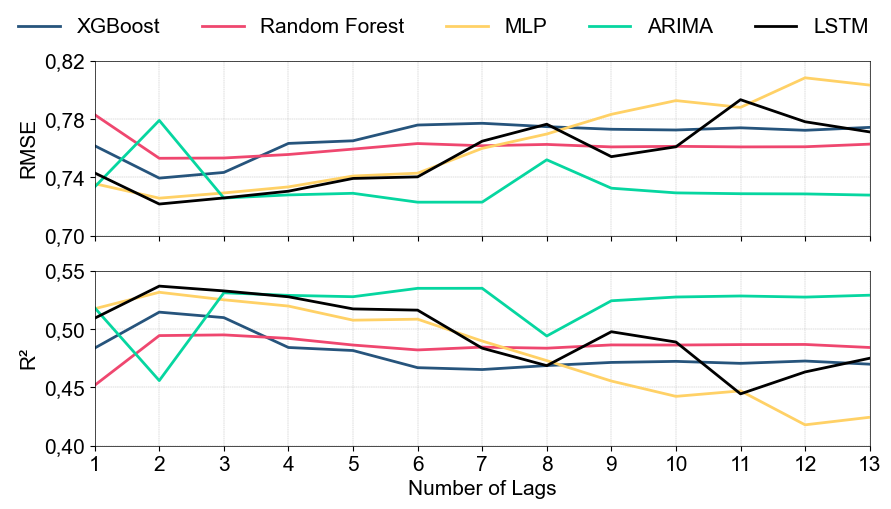

In [ ]:
lags = range(1, 14)

fig_all_models_lags, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(lags, rmse_list_xgb, label='XGBoost', c='#26547C')
ax[0].plot(lags, rmse_list_rf, label='Random Forest', c='#EF476F')
ax[0].plot(lags, rmse_list_mlp, label='MLP', c="#FFD166")
ax[0].plot(lags, rmse_list_arima, label='ARIMA', c='#06D6A0')
ax[0].plot(lags, rmse_list_lstm, label='LSTM', c="k")

ax[1].plot(lags, r2_list_xgb, label='XGBoost', c='#26547C')
ax[1].plot(lags, r2_list_rf, label='Random Forest', c='#EF476F')
ax[1].plot(lags, r2_list_mlp, label='MLP', c='#FFD166')
ax[1].plot(lags, r2_list_arima, label='ARIMA', c='#06D6A0')
ax[1].plot(lags, r2_list_lstm, label='LSTM', c='k')

ax[0].set_ylabel('RMSE')
ax[1].set_ylabel('R²')
ax[1].set_xlabel('Number of Lags')

ax[0].legend(ncols=5, loc='upper center', bbox_to_anchor=(0.45, 1.35), frameon=False)
ax[1].set_xticks(range(1, 14))
ax[1].set_xlim(1, 13)

ax[0].set_yticks(np.arange(0.7, 0.83, 0.04))
ax[1].set_yticks(np.arange(0.4, 0.55, 0.05))

ax[0].grid(lw=0.3) 
ax[1].grid(lw=0.3) 

plt.show()

In [24]:
print(f'Average RMSE across folds: {np.mean(scores)}')
print(f'RMSE scores for each fold: {scores}')
print(f"Melhor modelo: Fold {best_fold} | RMSE = {best_rmse:.4f}")

Average RMSE across folds: 0.6921170197931963
RMSE scores for each fold: [0.7079480434751928, 0.7552039915329253, 0.6149589948728331, 0.6403161289322098, 0.7421579401528205]
Melhor modelo: Fold 2 | RMSE = 0.6150


In [25]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.2f}')

Root Mean Squared Error: 0.74
Mean Absolute Error: 0.52
R^2 Score: 0.62


### 4.1 - Ploting Model Results

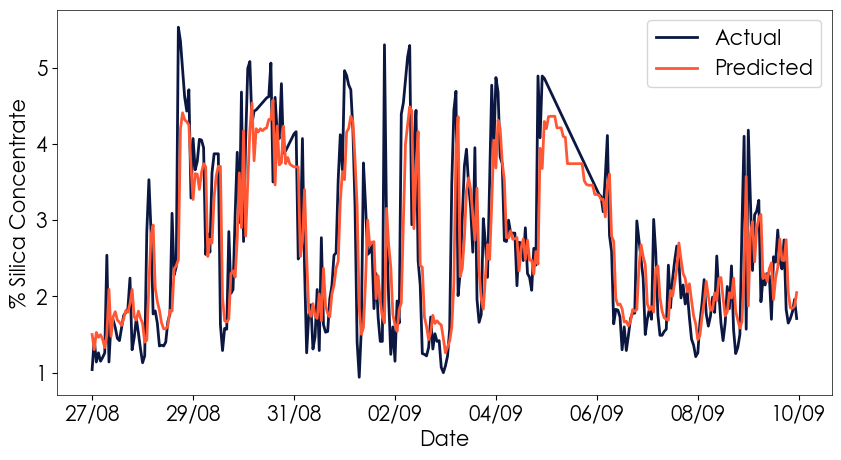

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(y_test.index, y_test, label='Actual', c='#0B1741')
ax.plot(y_test.index, y_pred, label='Predicted', c='#FF5733')   

ax.set_ylabel('% Silica Concentrate')
ax.set_xlabel('Date')
ax.legend(loc='upper right')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

ax.set_xticks([pd.Timestamp('2017-08-27'), pd.Timestamp('2017-08-29'), pd.Timestamp('2017-08-31'), pd.Timestamp('2017-09-02'),
               pd.Timestamp('2017-09-04'), pd.Timestamp('2017-09-06'), pd.Timestamp('2017-09-08'), pd.Timestamp('2017-09-10')])

# fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\fm_sc_prediction.svg', dpi=140, format='svg', transparent=True)

plt.show()

In [27]:
results = model.evals_result_
print(results.keys())

AttributeError: 'XGBRegressor' object has no attribute 'evals_result_'

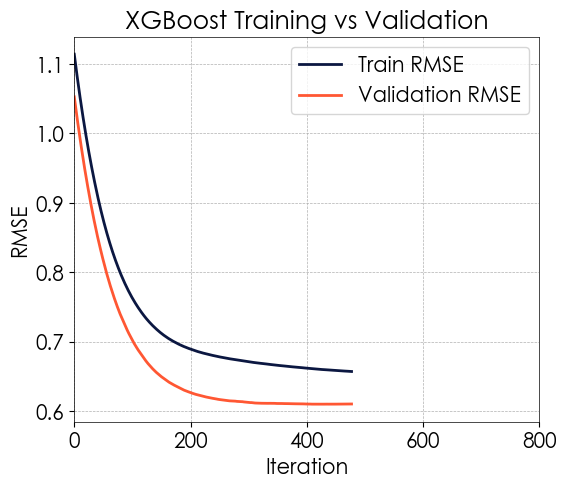

In [ ]:
train_rmse = results['validation_0']['rmse']
val_rmse   = results['validation_1']['rmse']

fig_error, ax = plt.subplots(figsize=(6, 5))

ax.plot(train_rmse, label='Train RMSE', c='#0B1741')
ax.plot(val_rmse, label='Validation RMSE', c='#FF5733')

ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Training vs Validation')
ax.legend()

ax.grid(True)
ax.set_xlim(0, 800)

# fig_error.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\fm_sc_errors_02.svg', dpi=140, format='svg', transparent=True)

plt.show()

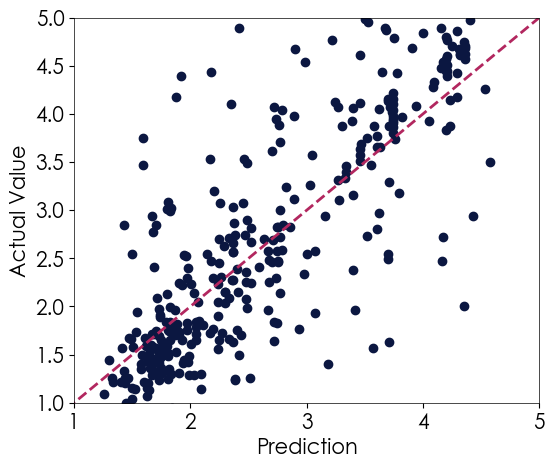

In [ ]:
fig_scatter_error, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_pred, y_test, c='#0B1741')
ax.plot([0, 5], [0, 5], color='#B2275F', ls='--')

ax.set_xlabel('Prediction')
ax.set_ylabel('Actual Value')

ax.set_ylim(1, 5)
ax.set_xlim(1, 5)

plt.show()

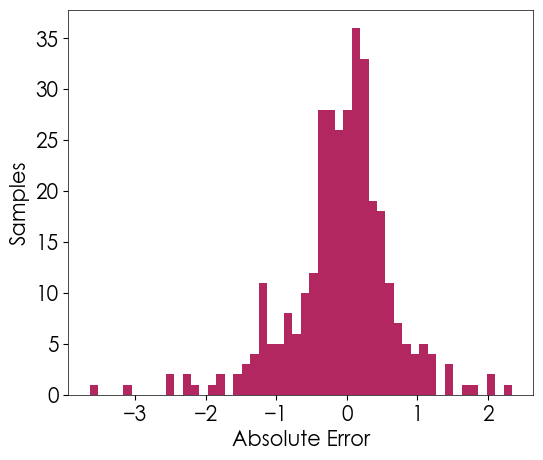

In [ ]:
fig_hist_error, ax = plt.subplots(figsize=(6, 5))

ax.hist(y_pred - y_test, bins=50, color='#B2275F')

ax.set_xlabel('Absolute Error')
ax.set_ylabel('Samples')

plt.show()

# 05 - Predicting the Future

In [ ]:
future = 24 * 2 # in hours (1 day)

X_test_future = X_test.iloc[-future:]

In [ ]:
for i in range(future):
    if i == 0:
        y_pred_future = model.predict(X_test_future.iloc[[i]])
    else:
        X_test_future.iloc[[i], 0] = y_pred_future
        
        print(y_pred_future)
        for j in range(1, X_test_future.shape[1] - 1):
            X_test_future.iloc[[i], j] = X_test_future.iloc[[i], j + 1]
        
        y_pred_future = model.predict(X_test_future.iloc[[i]])

In [ ]:
y_test_future = y_test.iloc[-future:].copy()

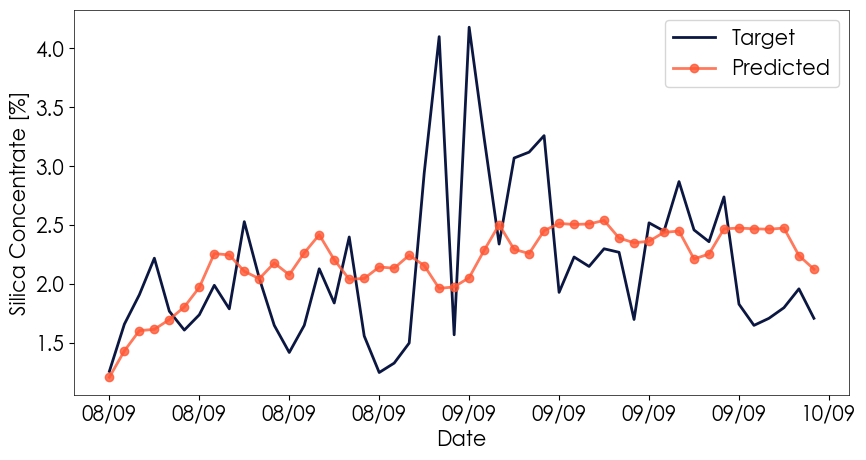

In [ ]:
fig_fut, ax = plt.subplots(figsize=(10, 5))

ax.plot(y_test_future, c='#0B1741', label='Target')
ax.plot(X_test_future.index, X_test_future['lag-1'], c='#FF5733', label='Predicted', marker='o', alpha=0.8)

ax.set_ylabel('Silica Concentrate [%]')
ax.set_xlabel('Date')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

ax.legend()

# fig_fut.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\future-predict.svg', dpi=140, format='svg', transparent=True)

plt.show()

The chart demonstrates that the model is capable of predicting up to a 3-hour horizon with relative low errors.

---